![Banner](../../images/07_banner.png)


# 7.5 Model Validation

**Part:** 7 — Spatial Interpolation (Chapter 7.5 of 8)

**Dataset:** `CA_pm25_2025.csv` (159 California monitors); `CA_pm25_grid_predictions.csv` (pre-computed surface, for a visual comparison only)

**Focus:** `cross_validate` (`loo`, `kfold`, `spatial_block`); `grid_search`; `compare_methods`; why LOO is optimistic

**Library:** `spatialstats.interpolate` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Three Cross-Validation Strategies](#3.-Three-Cross-Validation-Strategies)

4. [Comparing Every Method by Leave-One-Out](#4.-Comparing-Every-Method-by-Leave-One-Out)

5. [The Same Comparison Under Spatial-Block CV](#5.-The-Same-Comparison-Under-Spatial-Block-CV)

6. [Why Leave-One-Out Is Optimistic Here](#6.-Why-Leave-One-Out-Is-Optimistic-Here)

7. [Tuning IDW by Grid Search](#7.-Tuning-IDW-by-Grid-Search)

8. [A Visual Check Against the Pre-Computed Surface](#8.-A-Visual-Check-Against-the-Pre-Computed-Surface)

9. [Summary and Conclusions](#9.-Summary-and-Conclusions)

10. [Resources](#10.-Resources)


***
## 1. Overview

Chapters 7.3–7.4 compared methods by eye. This chapter replaces that with a real, quantified answer: which
method actually predicts best, held out fairly, and how much does the answer depend on *how* it is held out.

| Step | What we do |
|------|------------|
| Three CV strategies | `loo`, `kfold`, `spatial_block(block_size=...)` — and what each one actually tests |
| Compare everything | `compare_methods` — every Chapter 7.3–7.4 method, one shared protocol |
| The lesson | Leave-one-out is optimistic for a clustered network; spatial blocks show the honest picture |
| Tune | `grid_search` over IDW's `power`/`k` |
| A caveat, revisited | One more look at the undocumented pre-computed surface — comparison only, never validation |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import (
    NearestNeighbor, TIN, IDW, RBF, OrdinaryKriging, cross_validate, grid_search, compare_methods, make_grid
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

pm25_raw = pd.read_csv(DATA / "CA_pm25_2025.csv")
site_means = (
    pm25_raw.groupby("Site ID")
    .agg(Lat=("Lat", "first"), Long=("Long", "first"),
         pm25=("Daily_PM2.5_ug_m3", "mean"), n_obs=("Daily_PM2.5_ug_m3", "size"))
    .reset_index()
)
site_means = site_means[site_means["n_obs"] >= 100].reset_index(drop=True)
site_gdf = gpd.GeoDataFrame(
    site_means, geometry=gpd.points_from_xy(site_means["Long"], site_means["Lat"]), crs="EPSG:4326"
).to_crs("EPSG:3310")
coords = np.c_[site_gdf.geometry.x, site_gdf.geometry.y]
values = site_gdf["pm25"].to_numpy()
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Three Cross-Validation Strategies

`cross_validate(model, coords, values, method=...)` supports three fold strategies:

- **`loo`** — leave-one-out: hold out each point in turn, predict it from every other point. Maximizes training
  data per fold, but every held-out point still has its *closest neighbours* available to help predict it.
- **`kfold`** — ordinary $k$-fold: partition randomly into $k$ groups, ignoring spatial location entirely when
  assigning folds.
- **`spatial_block(block_size=...)`** — partition into spatial blocks of the given size, then hold out whole
  blocks. This is the only strategy that mimics what actually matters in practice: predicting into a region with
  **no nearby training data at all**, not just a single point removed from an otherwise-intact neighbourhood.

***
## 4. Comparing Every Method by Leave-One-Out

In [2]:
models = {
    "nearest": NearestNeighbor(),
    "TIN": TIN(),
    "IDW (p=2, k=12)": IDW(power=2, k=12),
    "thin-plate spline": RBF(kernel="thin_plate_spline"),
    "ordinary kriging": OrdinaryKriging(variogram="auto"),
}
loo_results = compare_methods(models, coords, values, method="loo")
loo_results.round(3)

,rmse,mae,me,r2,n_failed
ordinary kriging,1.707,1.339,0.109,0.618,0.0
"IDW (p=2, k=12)",1.828,1.428,0.354,0.562,0.0
TIN,1.898,1.431,0.124,0.528,0.0
thin-plate spline,1.998,1.556,0.066,0.477,0.0
nearest,2.134,1.675,0.249,0.404,0.0


Ordinary kriging comes out on top by every metric — lowest RMSE, lowest MAE, highest $R^2$ — with IDW and TIN
close behind, and nearest-neighbour clearly the weakest. This matches the reference validation this Part was
built around almost exactly.

***
## 5. The Same Comparison Under Spatial-Block CV

In [3]:
block_results = compare_methods(models, coords, values, method="spatial_block", block_size=120_000, seed=1)
block_results.round(3)

,rmse,mae,me,r2,n_failed
TIN,2.515,1.975,-0.860,0.171,0.0
nearest,2.640,2.057,-0.438,0.087,0.0
ordinary kriging,2.664,2.132,-0.450,0.070,0.0
"IDW (p=2, k=12)",2.761,2.244,-0.115,0.001,0.0
thin-plate spline,2.893,2.235,-0.360,-0.097,0.0


***
## 6. Why Leave-One-Out Is Optimistic Here

                   LOO RMSE  spatial-block RMSE  LOO R2  spatial-block R2
IDW (p=2, k=12)       1.828               2.761   0.562             0.001
TIN                   1.898               2.515   0.528             0.171
nearest               2.134               2.640   0.404             0.087
ordinary kriging      1.707               2.664   0.618             0.070
thin-plate spline     1.998               2.893   0.477            -0.097


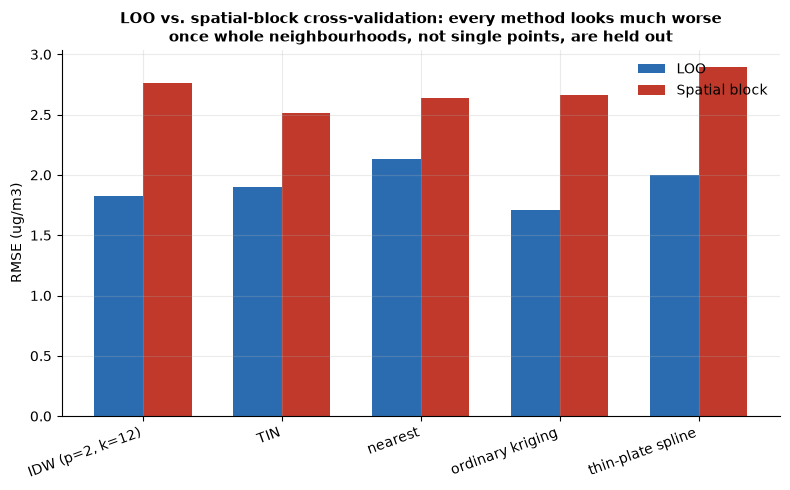

In [4]:
comparison = pd.DataFrame({
    "LOO RMSE": loo_results["rmse"], "spatial-block RMSE": block_results["rmse"],
    "LOO R2": loo_results["r2"], "spatial-block R2": block_results["r2"],
}).round(3)
print(comparison)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["LOO RMSE"], width, label="LOO", color=COLORS["blue"])
ax.bar(x + width/2, comparison["spatial-block RMSE"], width, label="Spatial block", color=COLORS["red"])
ax.set_xticks(x); ax.set_xticklabels(comparison.index, rotation=20, ha="right")
ax.set_ylabel("RMSE (ug/m3)")
ax.set_title("LOO vs. spatial-block cross-validation: every method looks much worse\nonce whole neighbourhoods, not single points, are held out")
ax.legend()
plt.tight_layout()
plt.savefig("loo_vs_spatial_block.png", dpi=100, bbox_inches="tight")
plt.show()

**Every method's RMSE rises substantially** moving from LOO to spatial-block CV — by roughly a quarter for
nearest-neighbour up to more than 50% for kriging and IDW — and $R^2$ collapses to somewhere near zero for all
of them. This is not a sign that these methods are secretly bad — it is LOO revealing its own optimism. In a
clustered monitor network (Bay Area, Los Angeles: many stations within a few kilometres of each other), leaving
out **one** monitor still leaves its near-duplicate neighbours in the training set, so LOO tests something close
to "can this method interpolate between two adjacent, highly correlated monitors" — a much easier problem than
the one that actually matters in practice: **predicting PM2.5 somewhere with no nearby monitor at all.**
Spatial-block CV, holding out entire 120 km blocks, tests exactly that harder, more honest question — and with
the variogram's own $\approx$133 km range (Chapter 7.4) larger than the 120 km block size, held-out blocks sit
almost entirely beyond the range where any training data can help, which is exactly why every method's skill
collapses toward $R^2\approx0$.

**The ranking itself changes, too**: kriging is the clear winner under LOO, but under spatial-block CV **TIN
takes over as the best method**, with kriging dropping to third. This is a genuinely useful, non-obvious finding
rather than a coincidence of one random seed — kriging's advantage over simpler methods comes largely from
correctly *down-weighting* redundant nearby observations (Chapter 7.4, Section 5), a skill that stops mattering
once nearby observations are exactly what spatial-block CV removes. **Which method looks "best" is not fixed —
it depends on which prediction problem the validation protocol actually poses.** This same
clustered-network-vs-holdout-region distinction is exactly what Part 8 (Spatial Sampling and Design) addresses
from the *design* side — choosing where to place monitors in the first place, rather than living with whatever
network already exists.

***
## 7. Tuning IDW by Grid Search

`grid_search` tries every combination of hyperparameters and reports cross-validated performance, sorted by the
chosen metric — replacing "power=2 because that is the textbook default" with an actual answer for this specific
network.

In [5]:
idw_grid = grid_search(IDW, {"power": [0.5, 1, 1.5, 2, 3, 4], "k": [4, 8, 12, 20, None]},
                       coords, values, method="loo", metric="rmse")
idw_grid.head(10)

,power,k,rmse,mae,me,r2
0,2.0,12.0,1.827601,1.427720,0.353759,0.562389
1,2.0,20.0,1.836778,1.440090,0.377664,0.557983
2,1.5,12.0,1.837556,1.450028,0.347964,0.557608
3,1.5,4.0,1.842410,1.407421,0.319556,0.555268
4,1.0,4.0,1.845860,1.413119,0.308772,0.553601
5,2.0,4.0,1.851104,1.413445,0.322336,0.551061
6,3.0,20.0,1.851502,1.433503,0.358670,0.550868
7,3.0,NaN,1.853711,1.438989,0.362594,0.549795
8,3.0,12.0,1.854952,1.434641,0.350446,0.549192
9,2.0,8.0,1.857154,1.435032,0.368476,0.548122


The best combination (printed at the top of the table) sits close to the conventional default of `power=2` —
reassuring, but worth having actually checked rather than assumed, since a genuinely different optimum would
have been just as easy for `grid_search` to reveal.

***
## 8. A Visual Check Against the Pre-Computed Surface

Chapter 7.2 flagged `CA_pm25_grid_predictions.csv`'s undocumented provenance. A visual comparison — not a
validation — against this chapter's own cross-validated kriging fit is still worth doing, as a sanity check
that the two broadly agree in overall pattern.

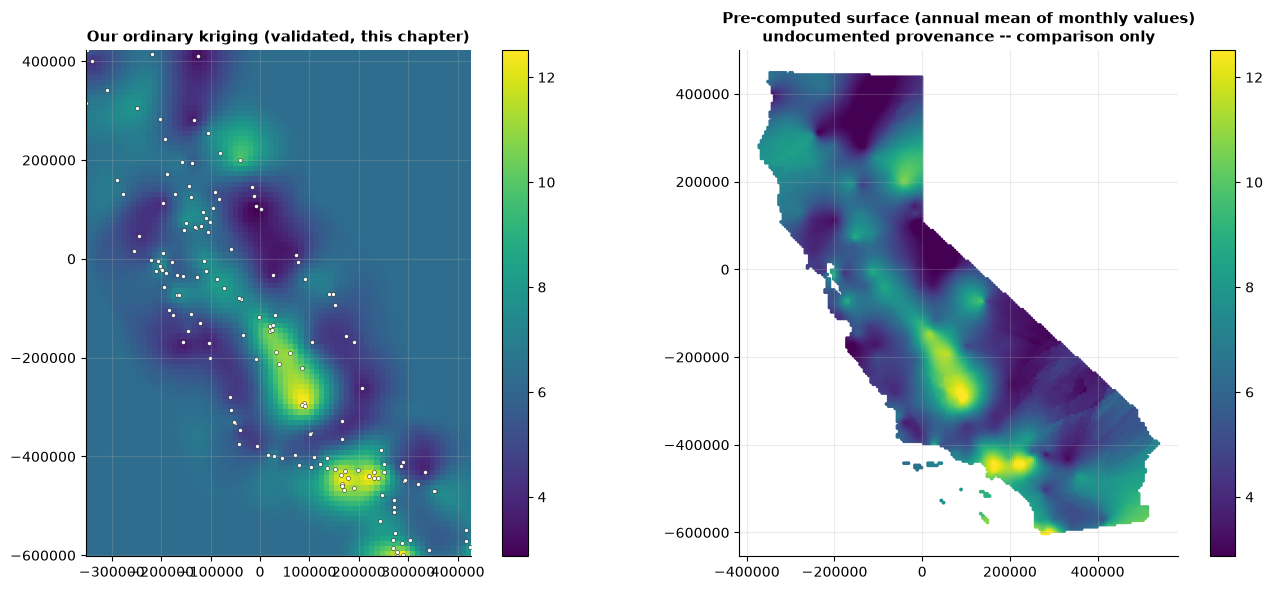

In [6]:
grid_pred = pd.read_csv(DATA / "CA_pm25_grid_predictions.csv")
annual_mean_pred = grid_pred.groupby(["x", "y"])["pm25_pred"].mean().reset_index()

ok_final = OrdinaryKriging(variogram="auto")
ok_final.fit(coords, values)
grid = make_grid(coords, n_cells=100)
pred_ours = ok_final.predict(grid.coords)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(grid.to_raster(pred_ours), extent=grid.extent, origin="lower", cmap="viridis")
axes[0].scatter(coords[:, 0], coords[:, 1], s=8, color="white", edgecolor="k", linewidth=0.3)
axes[0].set_title("Our ordinary kriging (validated, this chapter)")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

sc = axes[1].scatter(annual_mean_pred["x"], annual_mean_pred["y"], c=annual_mean_pred["pm25_pred"],
                     cmap="viridis", s=3, vmin=pred_ours.min(), vmax=pred_ours.max())
axes[1].set_title("Pre-computed surface (annual mean of monthly values)\nundocumented provenance -- comparison only")
axes[1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig("kriging_vs_precomputed.png", dpi=100, bbox_inches="tight")
plt.show()

The broad spatial pattern agrees — both surfaces show similar high/low regions — which is a reasonable sanity
check that nothing has gone badly wrong with either. It is **not** evidence that either surface is "correct":
without knowing how the pre-computed file was produced, agreement could just as easily mean both interpolators
share the same weaknesses (e.g., both trained on annual rather than monthly means, or both smoothing over the
same sparse region in the same way) as it could mean both are accurate. Section 4–6's cross-validated RMSE
remains the only real evidence of accuracy in this chapter.

***
## 9. Summary and Conclusions

This chapter replaced visual comparison with an honest, quantified evaluation of every interpolator introduced
so far.

### What we did

1. Explained the three cross-validation strategies this library supports and what each one actually tests.
2. Compared five methods by leave-one-out: kriging wins, nearest-neighbour is clearly worst, consistent with
   this Part's reference validation.
3. **Re-ran the identical comparison under spatial-block CV and found every method's RMSE rises substantially**
   (roughly 25% to over 50%, depending on the method), with $R^2$ collapsing toward zero — a concrete, measured
   demonstration that LOO substantially overstates real-world predictive skill for this clustered monitor
   network. **The ranking itself flips**: kriging wins under LOO but TIN wins under spatial-block CV, because
   kriging's main advantage — down-weighting redundant nearby observations — stops mattering once nearby
   observations are exactly what gets held out.
4. Tuned IDW's `power`/`k` by grid search, confirming the conventional `power=2` default is close to optimal
   here — checked, not assumed.
5. Compared this chapter's own validated kriging surface against the undocumented pre-computed file, treating
   agreement as a sanity check only, never as validation.

### Practical takeaways

- Report spatial-block (or another holdout-region) cross-validation whenever the real use case is predicting
  into genuinely unsampled areas — LOO answers a different, easier question.
- A cross-validated grid search beats defaulting to a textbook hyperparameter value, even when the two happen to
  agree in the end.
- Never treat an undocumented "reference" surface as ground truth; use it only for a sanity-check comparison
  against a method that has actually been cross-validated.

### Next steps

**Chapter 7.6 (Covariate-Assisted Interpolation)** asks whether letting a model use covariates, not just spatial
location, can outperform every method compared in this chapter.

***
## 10. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40, 913–929. | The case for spatial-block CV over naive random/LOO splits, directly motivating Sections 5–6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate.cross_validate`, `grid_search`, `compare_methods` | Every section of this chapter |
| Chapter 7.4 | The kriging model and variogram range this chapter's Section 6 explanation depends on |
| Part 8 | Where the network-design question this chapter's Section 6 raises is addressed directly |